In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/raw/student-mat.csv", sep=";")

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [7]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

In [8]:
df["G3"].value_counts().sort_index()

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64

In [9]:
df["performance"] = (df["G3"] >= 10).astype(int)

In [10]:
df["performance"].value_counts()

performance
1    265
0    130
Name: count, dtype: int64

In [11]:
df["performance"].value_counts(normalize=True)

performance
1    0.670886
0    0.329114
Name: proportion, dtype: float64

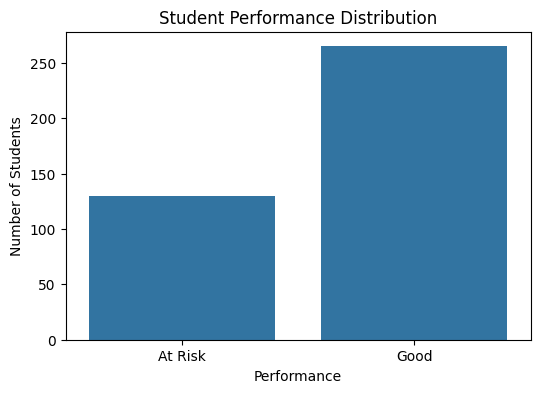

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="performance")

plt.title("Student Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Number of Students")
plt.xticks([0, 1], ["At Risk", "Good"])

plt.show()

In [13]:
df.duplicated().sum()

0

In [14]:
df.select_dtypes(include=np.number).columns

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3', 'performance'],
      dtype='object')

In [15]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,performance
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190,0.670886
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443,0.470487
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000,0.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000,1.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000,1.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000,1.000000


In [16]:
df[["age", "studytime", "failures", "absences", "G3"]].describe()

,age,studytime,failures,absences,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.035443,0.334177,5.708861,10.415190
std,1.276043,0.839240,0.743651,8.003096,4.581443
min,15.000000,1.000000,0.000000,0.000000,0.000000
25%,16.000000,1.000000,0.000000,0.000000,8.000000
50%,17.000000,2.000000,0.000000,4.000000,11.000000
75%,18.000000,2.000000,0.000000,8.000000,14.000000
max,22.000000,4.000000,3.000000,75.000000,20.000000


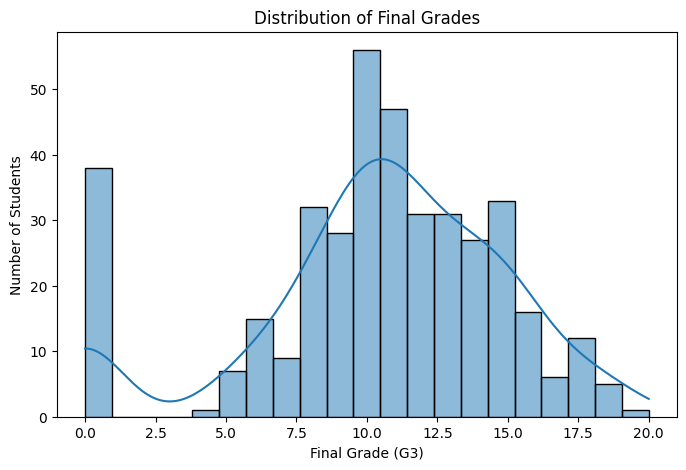

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(df["G3"], bins=21, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

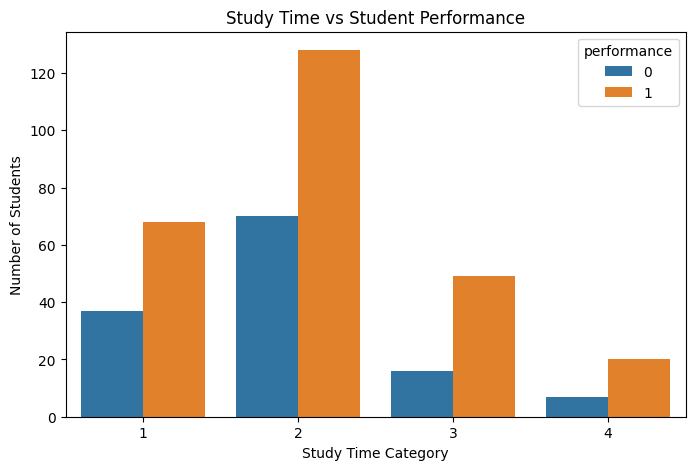

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="studytime",
    hue="performance"
)

plt.title("Study Time vs Student Performance")
plt.xlabel("Study Time Category")
plt.ylabel("Number of Students")

plt.show()

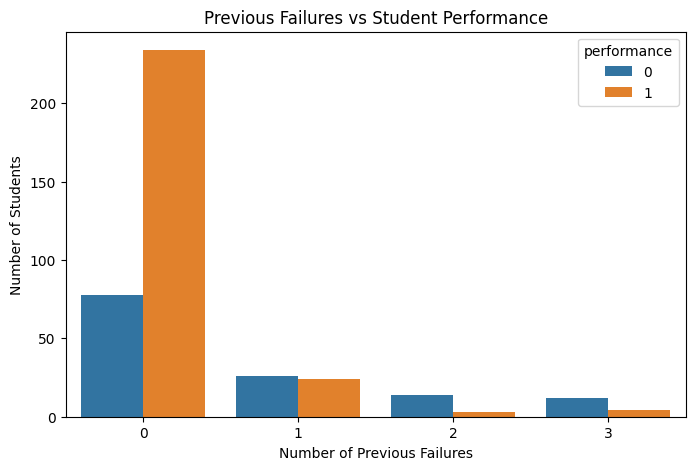

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="failures",
    hue="performance"
)

plt.title("Previous Failures vs Student Performance")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Number of Students")

plt.show()

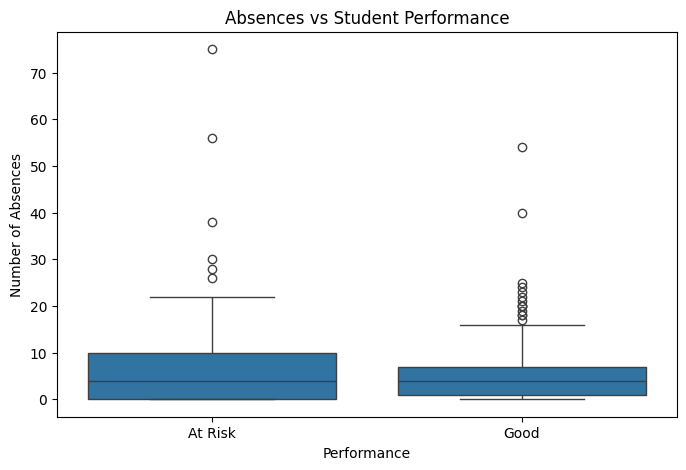

In [20]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="performance",
    y="absences"
)

plt.title("Absences vs Student Performance")
plt.xlabel("Performance")
plt.ylabel("Number of Absences")
plt.xticks([0, 1], ["At Risk", "Good"])

plt.show()

In [22]:
numeric_df = df.select_dtypes(include=np.number)
correlation = numeric_df.corr()

correlation["performance"].sort_values(ascending=False)

performance    1.000000
G3             0.770042
G2             0.725407
G1             0.664979
Medu           0.115396
Fedu           0.108057
studytime      0.074613
famrel         0.046683
freetime      -0.018321
Walc          -0.029957
traveltime    -0.044446
Dalc          -0.057343
health        -0.065668
absences      -0.092244
age           -0.179645
goout         -0.183399
failures      -0.337731
Name: performance, dtype: float64

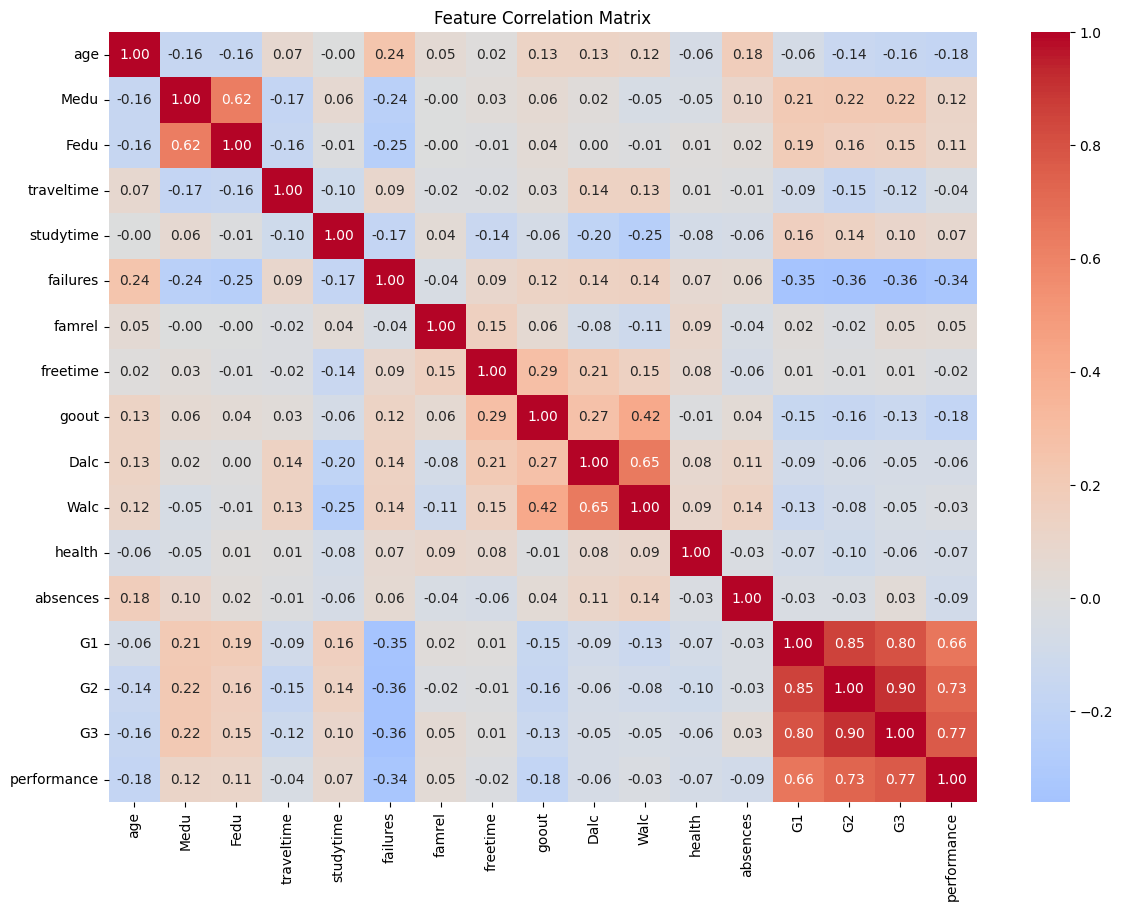

In [23]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [24]:
pd.crosstab(
    df["internet"],
    df["performance"],
    normalize="index"
) * 100

performance,0,1
internet,,
no,39.393939,60.606061
yes,31.610942,68.389058


In [25]:
pd.crosstab(
    df["schoolsup"],
    df["performance"],
    normalize="index"
) * 100

performance,0,1
schoolsup,,
no,31.104651,68.895349
yes,45.098039,54.901961


In [26]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

categorical_columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [27]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


school
school
GP    349
MS     46
Name: count, dtype: int64

sex
sex
F    208
M    187
Name: count, dtype: int64

address
address
U    307
R     88
Name: count, dtype: int64

famsize
famsize
GT3    281
LE3    114
Name: count, dtype: int64

Pstatus
Pstatus
T    354
A     41
Name: count, dtype: int64

Mjob
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64

Fjob
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64

reason
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64

guardian
guardian
mother    273
father     90
other      32
Name: count, dtype: int64

schoolsup
schoolsup
no     344
yes     51
Name: count, dtype: int64

famsup
famsup
yes    242
no     153
Name: count, dtype: int64

paid
paid
no     214
yes    181
Name: count, dtype: int64

activities
activities
yes    201
no     194
Name: count, dtype: int64

nu

In [28]:
features = [
    "school",
    "sex",
    "age",
    "address",
    "famsize",
    "Pstatus",
    "Medu",
    "Fedu",
    "Mjob",
    "Fjob",
    "reason",
    "guardian",
    "traveltime",
    "studytime",
    "failures",
    "schoolsup",
    "famsup",
    "paid",
    "activities",
    "nursery",
    "higher",
    "internet",
    "romantic",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences"
]

X = df[features]
y = df["performance"]

In [31]:
X.shape
y.shape

(395,)

In [32]:
"G3" in X.columns

False

In [33]:
"G1" in X.columns

False

In [34]:
"G2" in X.columns

False